In [29]:
import os
import matplotlib.pyplot as plt

output_dir = os.path.join("..", "figuras", "extra")
os.makedirs(output_dir, exist_ok=True)

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\1069248826.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\1069248826.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\1069248826.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\1069248826.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, tic

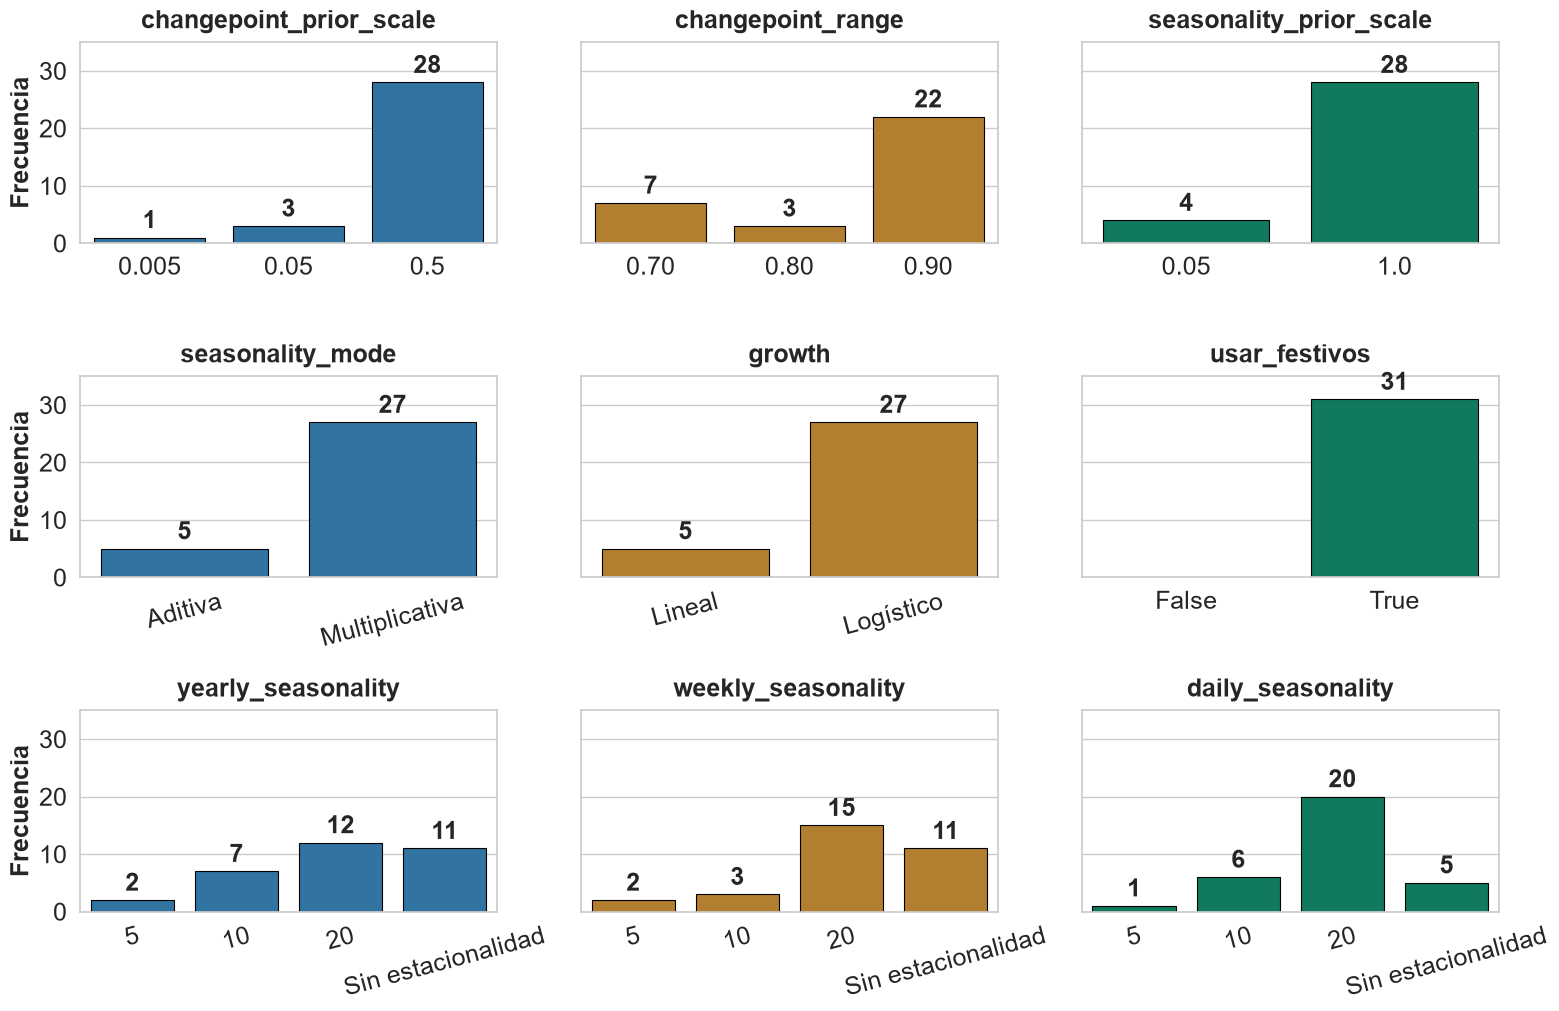

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de estilo global
sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
    }
)

# 1. Datos organizados según tu tabla
data = {
    "changepoint_prior_scale": {"0.005": 1, "0.05": 3, "0.5": 28},
    "changepoint_range": {"0.70": 7, "0.80": 3, "0.90": 22},
    "seasonality_prior_scale": {"0.05": 4, "1.0": 28},
    "seasonality_mode": {"Aditiva": 5, "Multiplicativa": 27},
    "growth": {"Lineal": 5, "Logístico": 27},
    "usar_festivos": {"False": 0, "True": 31},
    "yearly_seasonality": {
        "5": 2,
        "10": 7,
        "20": 12,
        "Sin estacionalidad": 11,
    },
    "weekly_seasonality": {
        "5": 2,
        "10": 3,
        "20": 15,
        "Sin estacionalidad": 11,
    },
    "daily_seasonality": {
        "5": 1,
        "10": 6,
        "20": 20,
        "Sin estacionalidad": 5
    },
}

# 2. Crear la figura de 3 filas x 3 columnas
fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 11),
    sharey=True
)

axes = axes.flatten()

# Paleta de colores
colors = ["#1f77b4", "#c88219", "#008a65"]

# 3. Dibujar cada subplot
for i, (param_name, param_data) in enumerate(data.items()):

    ax = axes[i]

    # Convertir dict a DataFrame para Seaborn
    df_temp = pd.DataFrame(
        list(param_data.items()),
        columns=["Valor", "Frecuencia"]
    )

    # Asignar color alternado por gráfico según la columna
    color = colors[i % 3]

    # Gráficos de barras
    bars = sns.barplot(
        data=df_temp,
        x="Valor",
        y="Frecuencia",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8,
    )

    # -------------------------------------------------------------------------
    # TÍTULOS Y EJES
    # -------------------------------------------------------------------------

    ax.set_title(
        param_name,
        pad=10,
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Frecuencia" if i % 3 == 0 else "",
        fontsize=18
    )

    ax.set_ylim(0, 35)

    # Tamaño de los valores de los ejes
    ax.tick_params(
        axis="x",
        labelsize=18
    )

    ax.tick_params(
        axis="y",
        labelsize=18
    )

    # -------------------------------------------------------------------------
    # NÚMEROS ENCIMA DE LAS BARRAS
    # -------------------------------------------------------------------------

    for p in bars.patches:

        height = p.get_height()

        if height > 0:

            ax.annotate(
                f"{int(height)}",
                (
                    p.get_x() + p.get_width() / 2.0,
                    height
                ),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                fontsize=18,
                fontweight="bold",
            )

    # -------------------------------------------------------------------------
    # ETIQUETAS DEL EJE X
    # -------------------------------------------------------------------------

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15
        if any(
            len(l.get_text()) > 8
            for l in ax.get_xticklabels()
        )
        else 0,
        fontsize=18
    )


# 4. Ajustar título principal y diseño general
plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

# Mostrar / Guardar
file_path = os.path.join(
    output_dir,
    "hiperparametros_prophet_barras.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

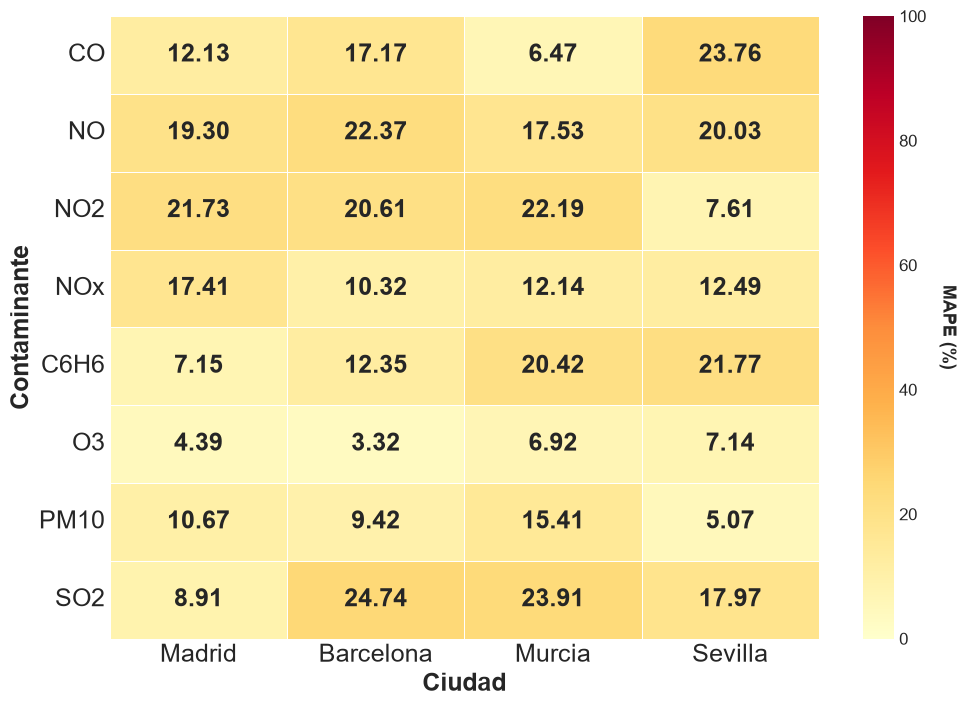

In [31]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# -----------------------------------------------------------------------------
# 1. ESTRUCTURA DE LOS DATOS CON LOS ERRORES MAPE
# -----------------------------------------------------------------------------

data = {
    "Madrid": {
        "CO": 12.13,
        "NO": 19.30,
        "NO2": 21.73,
        "NOx": 17.41,
        "C6H6": 7.15,
        "O3": 4.39,
        "PM10": 10.67,
        "SO2": 8.91,
    },
    "Barcelona": {
        "CO": 17.17,
        "NO": 22.37,
        "NO2": 20.61,
        "NOx": 10.32,
        "C6H6": 12.35,
        "O3": 3.32,
        "PM10": 9.42,
        "SO2": 24.74,
    },
    "Murcia": {
        "CO": 6.47,
        "NO": 17.53,
        "NO2": 22.19,
        "NOx": 12.14,
        "C6H6": 20.42,
        "O3": 6.92,
        "PM10": 15.41,
        "SO2": 23.91,
    },
    "Sevilla": {
        "CO": 23.76,
        "NO": 20.03,
        "NO2": 7.61,
        "NOx": 12.49,
        "C6H6": 21.77,
        "O3": 7.14,
        "PM10": 5.07,
        "SO2": 17.97,
    },
}


# -----------------------------------------------------------------------------
# 2. CONVERSIÓN DEL DICCIONARIO EN DATAFRAME
# -----------------------------------------------------------------------------

df = pd.DataFrame(data)


# -----------------------------------------------------------------------------
# 3. CONFIGURACIÓN DEL TAMAÑO DE LA FIGURA
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")


# -----------------------------------------------------------------------------
# 4. CREACIÓN DEL MAPA DE CALOR
# -----------------------------------------------------------------------------

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,

    # Tamaño de los números dentro de las celdas
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },

    # Barra de color
    cbar_kws={
        "label": "MAPE (%)"
    }
)


# -----------------------------------------------------------------------------
# 5. TÍTULO Y ETIQUETAS
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)


# -----------------------------------------------------------------------------
# 6. TAMAÑO DE LAS ETIQUETAS DE LOS EJES
# -----------------------------------------------------------------------------

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# Quitamos las marcas de los ejes.
ax.tick_params(
    axis="both",
    length=0
)


# -----------------------------------------------------------------------------
# 7. FORMATO DE LA BARRA DE COLOR
# -----------------------------------------------------------------------------

cbar = ax.collections[0].colorbar

# Tamaño de los números de la barra
cbar.ax.tick_params(
    labelsize=12,
    length=0
)

# Tamaño de la etiqueta "MAPE (%)"
cbar.ax.set_ylabel(
    "MAPE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)


# -----------------------------------------------------------------------------
# 8. AJUSTE DEL DISEÑO
# -----------------------------------------------------------------------------

plt.tight_layout()


# -----------------------------------------------------------------------------
# 9. GUARDADO Y VISUALIZACIÓN
# -----------------------------------------------------------------------------

file_path = os.path.join(
    output_dir,
    "mapa_calor_mape_prophet.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

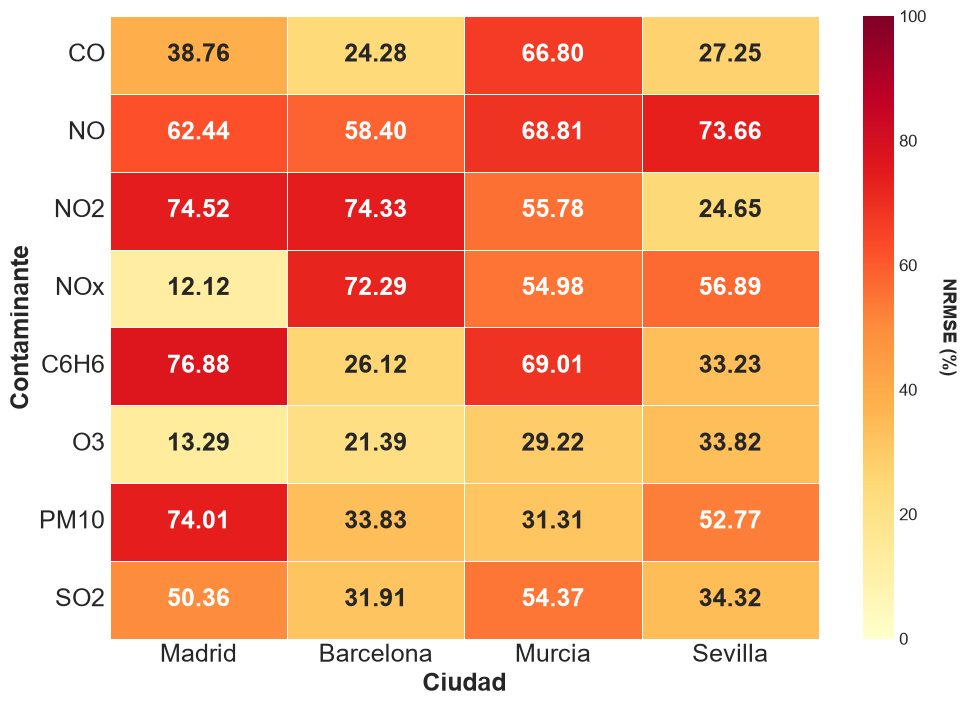

In [32]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# -----------------------------------------------------------------------------
# 1. ESTRUCTURA DE LOS DATOS CON LOS ERRORES NRMSE
# -----------------------------------------------------------------------------

data = {
    "Madrid": {
        "CO": 38.76,
        "NO": 62.44,
        "NO2": 74.52,
        "NOx": 12.12,
        "C6H6": 76.88,
        "O3": 13.29,
        "PM10": 74.01,
        "SO2": 50.36,
    },
    "Barcelona": {
        "CO": 24.28,
        "NO": 58.40,
        "NO2": 74.33,
        "NOx": 72.29,
        "C6H6": 26.12,
        "O3": 21.39,
        "PM10": 33.83,
        "SO2": 31.91,
    },
    "Murcia": {
        "CO": 66.80,
        "NO": 68.81,
        "NO2": 55.78,
        "NOx": 54.98,
        "C6H6": 69.01,
        "O3": 29.22,
        "PM10": 31.31,
        "SO2": 54.37,
    },
    "Sevilla": {
        "CO": 27.25,
        "NO": 73.66,
        "NO2": 24.65,
        "NOx": 56.89,
        "C6H6": 33.23,
        "O3": 33.82,
        "PM10": 52.77,
        "SO2": 34.32,
    },
}


# -----------------------------------------------------------------------------
# 2. CONVERSIÓN DEL DICCIONARIO EN DATAFRAME
# -----------------------------------------------------------------------------

df = pd.DataFrame(data)


# -----------------------------------------------------------------------------
# 3. CONFIGURACIÓN DEL TAMAÑO DE LA FIGURA
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")


# -----------------------------------------------------------------------------
# 4. CREACIÓN DEL MAPA DE CALOR
# -----------------------------------------------------------------------------

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,

    # Tamaño de los números dentro de las celdas
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },

    # Barra de color
    cbar_kws={
        "label": "NRMSE (%)"
    }
)


# -----------------------------------------------------------------------------
# 5. TÍTULO Y ETIQUETAS
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)


# -----------------------------------------------------------------------------
# 6. TAMAÑO DE LAS ETIQUETAS DE LOS EJES
# -----------------------------------------------------------------------------

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# Quitamos las marcas de los ejes.
ax.tick_params(
    axis="both",
    length=0
)


# -----------------------------------------------------------------------------
# 7. FORMATO DE LA BARRA DE COLOR
# -----------------------------------------------------------------------------

cbar = ax.collections[0].colorbar

# Tamaño de los números de la barra
cbar.ax.tick_params(
    labelsize=12,
    length=0
)

# Tamaño de la etiqueta "NRMSE (%)"
cbar.ax.set_ylabel(
    "NRMSE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)


# -----------------------------------------------------------------------------
# 8. AJUSTE DEL DISEÑO
# -----------------------------------------------------------------------------

plt.tight_layout()


# -----------------------------------------------------------------------------
# 9. GUARDADO Y VISUALIZACIÓN
# -----------------------------------------------------------------------------

file_path = os.path.join(
    output_dir,
    "mapa_calor_nrmse_prophet.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\2128744493.py:255: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\2128744493.py:255: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\2128744493.py:255: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\2128744493.py:255: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, tic

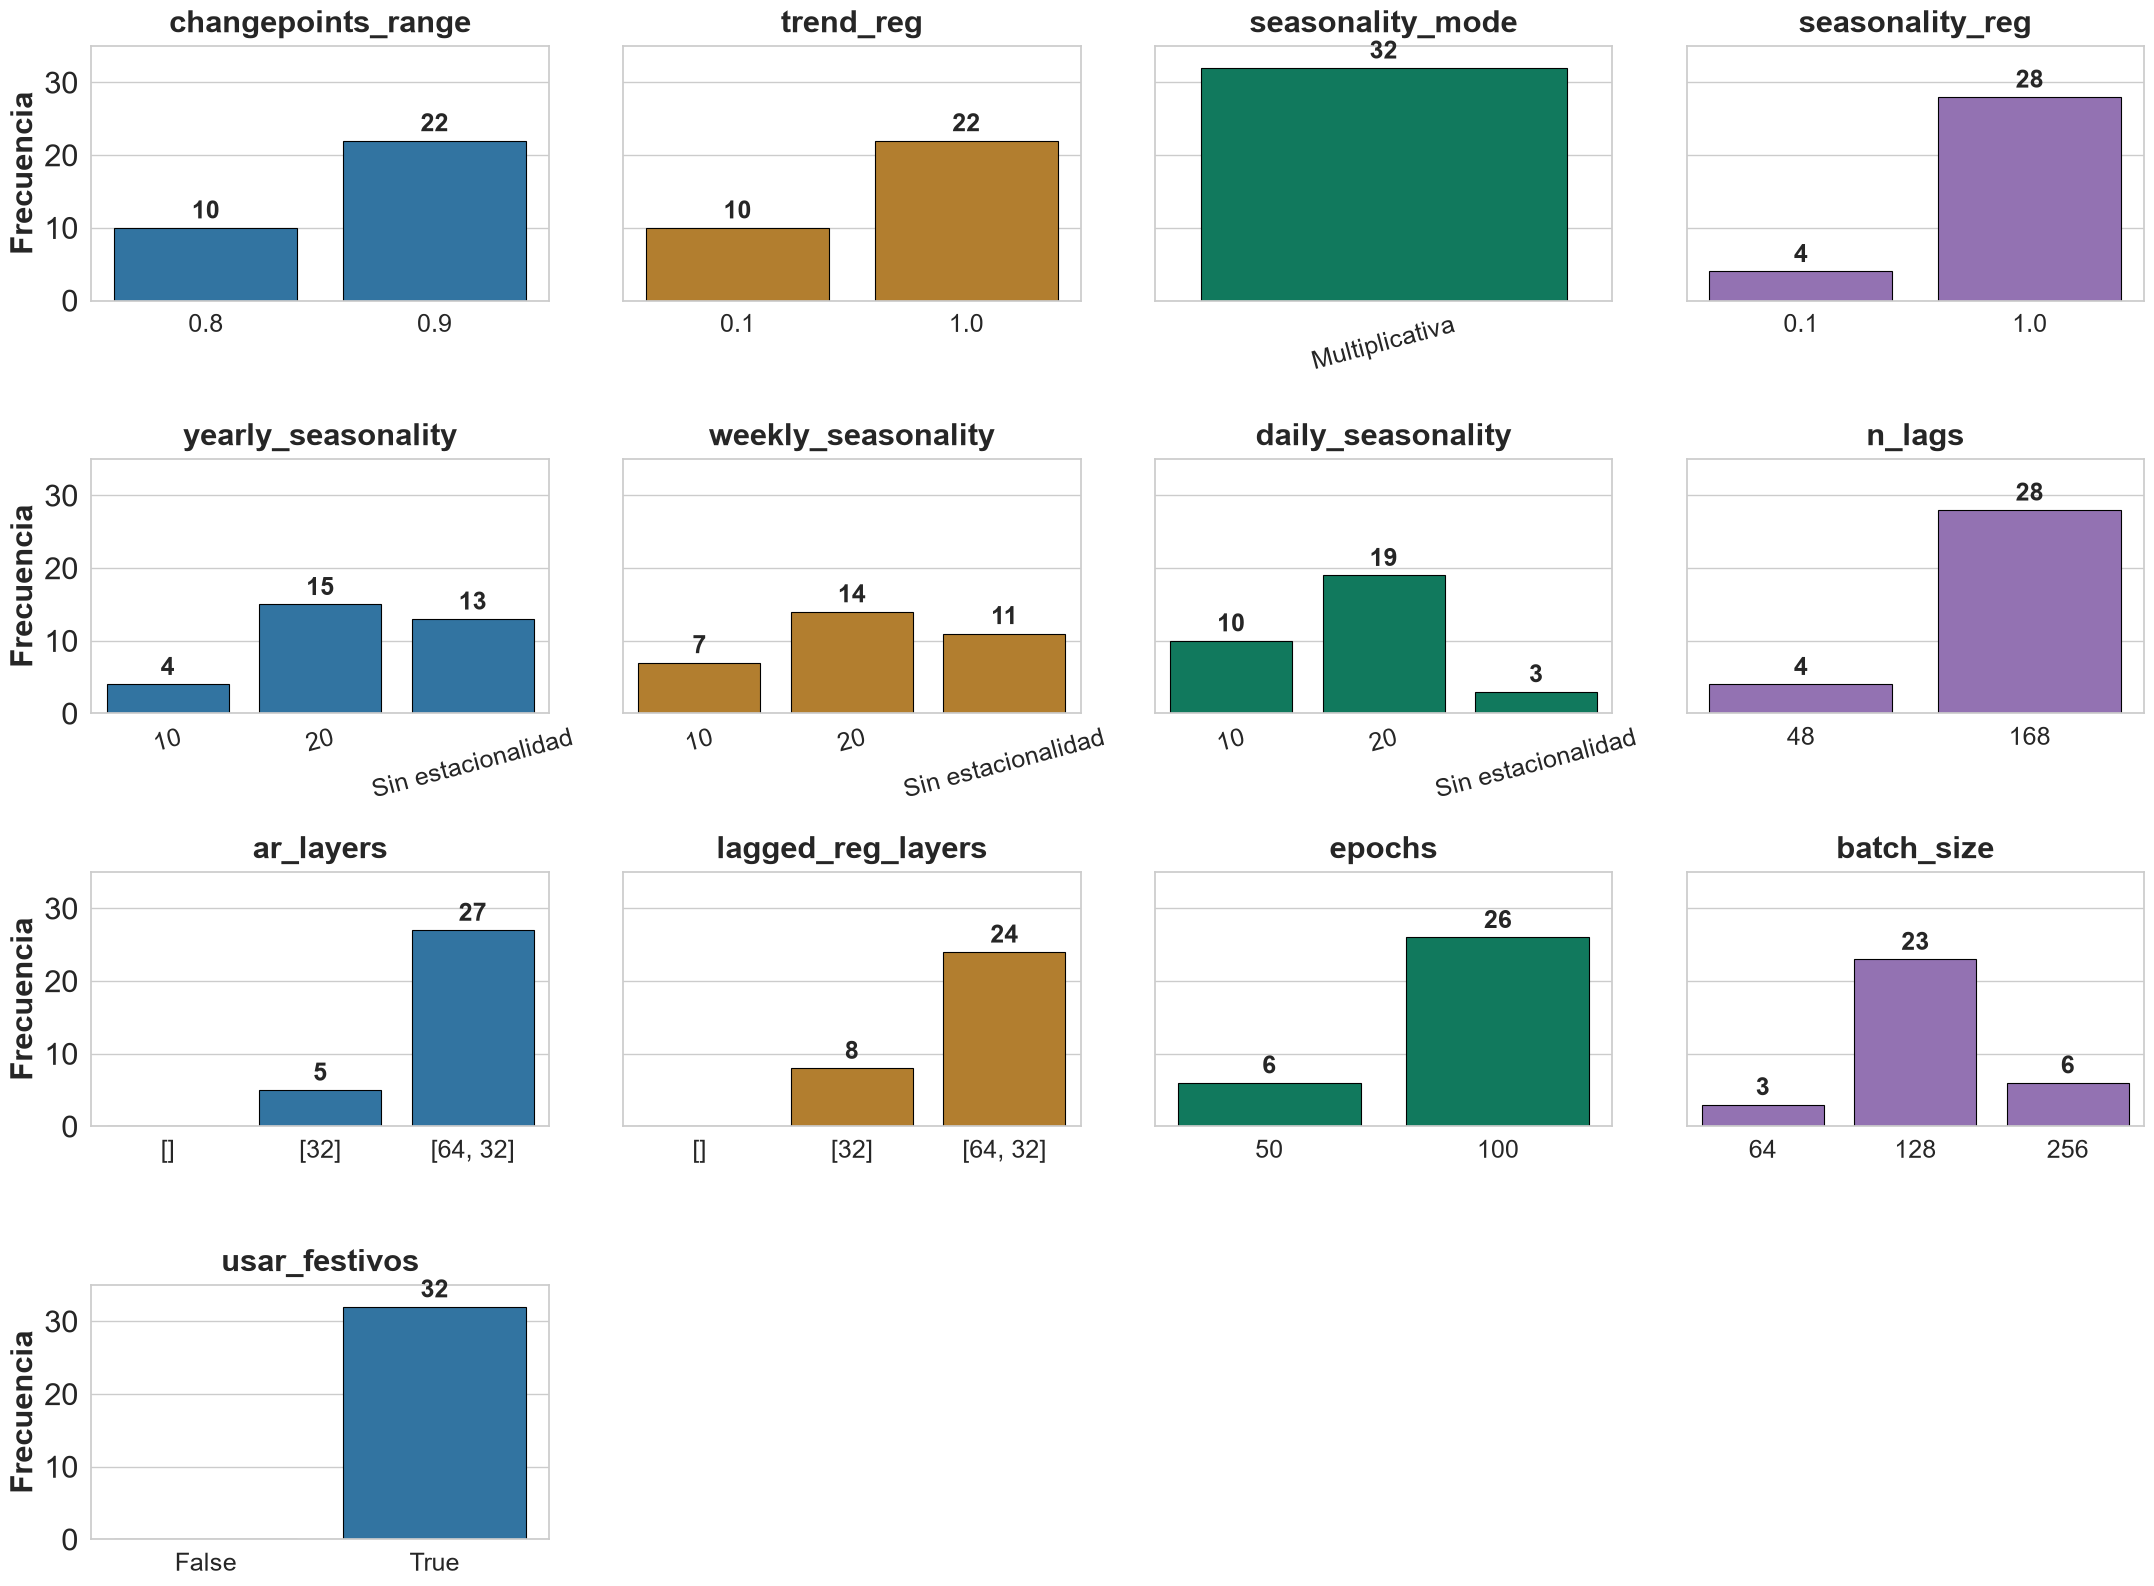

In [33]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ==============================================================================
# Configuración del estilo
# ==============================================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 22,
        "axes.titlesize": 22,
        "axes.titleweight": "bold",
        "axes.labelsize": 22,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
    }
)


# ==============================================================================
# Frecuencia de selección de los hiperparámetros
# ==============================================================================

data = {

    # --------------------------------------------------------------------------
    # Tendencia
    # --------------------------------------------------------------------------
    "changepoints_range": {
        "0.8": 10,
        "0.9": 22
    },

    "trend_reg": {
        "0.1": 10,
        "1.0": 22
    },


    # --------------------------------------------------------------------------
    # Estacionalidad
    # --------------------------------------------------------------------------
    "seasonality_mode": {
        "Multiplicativa": 32
    },

    "seasonality_reg": {
        "0.1": 4,
        "1.0": 28
    },

    "yearly_seasonality": {
        "10": 4,
        "20": 15,
        "Sin estacionalidad": 13
    },

    "weekly_seasonality": {
        "10": 7,
        "20": 14,
        "Sin estacionalidad": 11
    },

    "daily_seasonality": {
        "10": 10,
        "20": 19,
        "Sin estacionalidad": 3
    },


    # --------------------------------------------------------------------------
    # Autorregresión
    # --------------------------------------------------------------------------
    "n_lags": {
        "48": 4,
        "168": 28
    },

    "ar_layers": {
        "[]": 0,
        "[32]": 5,
        "[64, 32]": 27
    },

    "lagged_reg_layers": {
        "[]": 0,
        "[32]": 8,
        "[64, 32]": 24
    },


    # --------------------------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------------------------
    "epochs": {
        "50": 6,
        "100": 26
    },

    "batch_size": {
        "64": 3,
        "128": 23,
        "256": 6
    },


    # --------------------------------------------------------------------------
    # Festivos
    # --------------------------------------------------------------------------
    "usar_festivos": {
        "False": 0,
        "True": 32
    }
}


# ==============================================================================
# Creación de la figura
# ==============================================================================

fig, axes = plt.subplots(
    4,
    4,
    figsize=(22, 17),
    sharey=True
)

axes = axes.flatten()


# ==============================================================================
# Colores
# ==============================================================================

colors = [
    "#1f77b4",
    "#c88219",
    "#008a65",
    "#9467bd"
]


# ==============================================================================
# Representación de cada hiperparámetro
# ==============================================================================

for i, (param_name, param_data) in enumerate(data.items()):

    ax = axes[i]

    # --------------------------------------------------------------------------
    # Conversión del diccionario en DataFrame
    # --------------------------------------------------------------------------

    df_temp = pd.DataFrame(
        list(param_data.items()),
        columns=[
            "Valor",
            "Frecuencia"
        ]
    )

    # Color alternado según la columna
    color = colors[i % 4]

    # --------------------------------------------------------------------------
    # Diagrama de barras
    # --------------------------------------------------------------------------

    bars = sns.barplot(
        data=df_temp,
        x="Valor",
        y="Frecuencia",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------------------
    # Título y ejes
    # --------------------------------------------------------------------------

    ax.set_title(
        param_name,
        pad=10,
        fontsize=22,
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Frecuencia"
        if i % 4 == 0
        else "",
        fontsize=22
    )

    ax.set_ylim(
        0,
        35
    )

    # Tamaño de los valores de los ejes
    ax.tick_params(
        axis="x",
        labelsize=22
    )

    ax.tick_params(
        axis="y",
        labelsize=22
    )

    # --------------------------------------------------------------------------
    # Frecuencia sobre cada barra
    # --------------------------------------------------------------------------

    for p in bars.patches:

        height = p.get_height()

        if height > 0:

            ax.annotate(
                f"{int(height)}",
                (
                    p.get_x() + p.get_width() / 2.0,
                    height
                ),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                fontsize=18,
                fontweight="bold"
            )

    # --------------------------------------------------------------------------
    # Rotación de etiquetas largas
    # --------------------------------------------------------------------------

    etiquetas = [
        etiqueta.get_text()
        for etiqueta in ax.get_xticklabels()
    ]

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15
        if any(
            len(etiqueta) > 8
            for etiqueta in etiquetas
        )
        else 0,
        fontsize=18
    )


# ==============================================================================
# Eliminación de los subplots vacíos
# ==============================================================================

for j in range(
    len(data),
    len(axes)
):

    fig.delaxes(
        axes[j]
    )


# ==============================================================================
# Título principal y ajuste del diseño
# ==============================================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


# ==============================================================================
# Guardado de la figura
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "hiperparametros_neuralprophet_barras.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

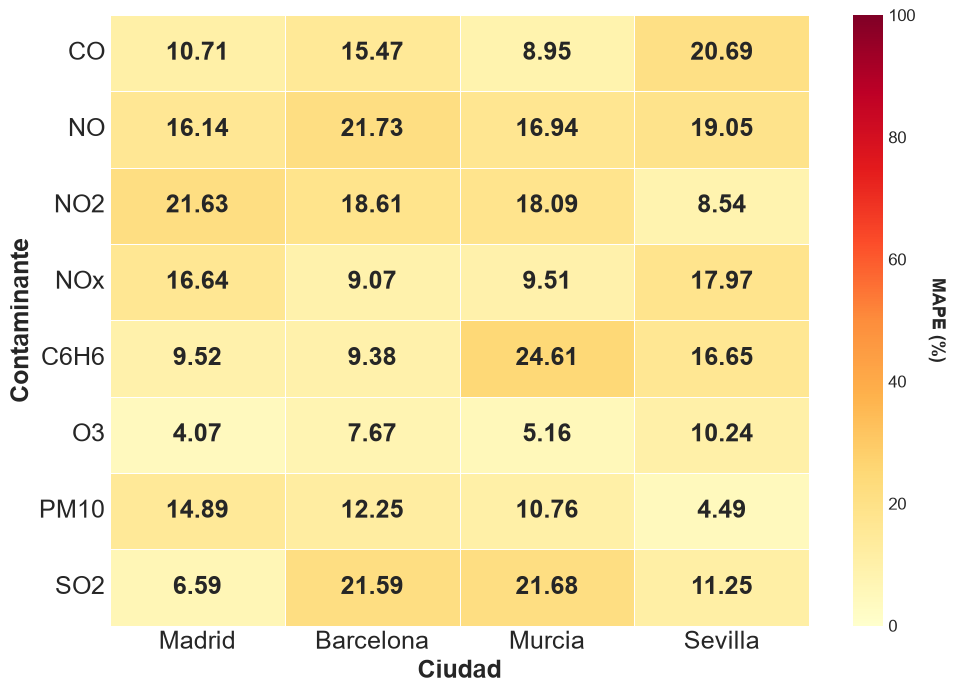

In [34]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ==============================================================================
# Datos de los errores MAPE de los modelos NeuralProphet
# ==============================================================================

data = {
    "Madrid": {
        "CO": 10.71,
        "NO": 16.14,
        "NO2": 21.63,
        "NOx": 16.64,
        "C6H6": 9.52,
        "O3": 4.07,
        "PM10": 14.89,
        "SO2": 6.59,
    },

    "Barcelona": {
        "CO": 15.47,
        "NO": 21.73,
        "NO2": 18.61,
        "NOx": 9.07,
        "C6H6": 9.38,
        "O3": 7.67,
        "PM10": 12.25,
        "SO2": 21.59,
    },

    "Murcia": {
        "CO": 8.95,
        "NO": 16.94,
        "NO2": 18.09,
        "NOx": 9.51,
        "C6H6": 24.61,
        "O3": 5.16,
        "PM10": 10.76,
        "SO2": 21.68,
    },

    "Sevilla": {
        "CO": 20.69,
        "NO": 19.05,
        "NO2": 8.54,
        "NOx": 17.97,
        "C6H6": 16.65,
        "O3": 10.24,
        "PM10": 4.49,
        "SO2": 11.25,
    },
}


# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_mape_neuralprophet = pd.DataFrame(data)


# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")


# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_mape_neuralprophet,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "MAPE (%)"
    }
)


# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

ax.tick_params(
    axis="both",
    length=0
)


# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=12,
    length=0
)

cbar.ax.set_ylabel(
    "MAPE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)


# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()


# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_mape_neuralprophet.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

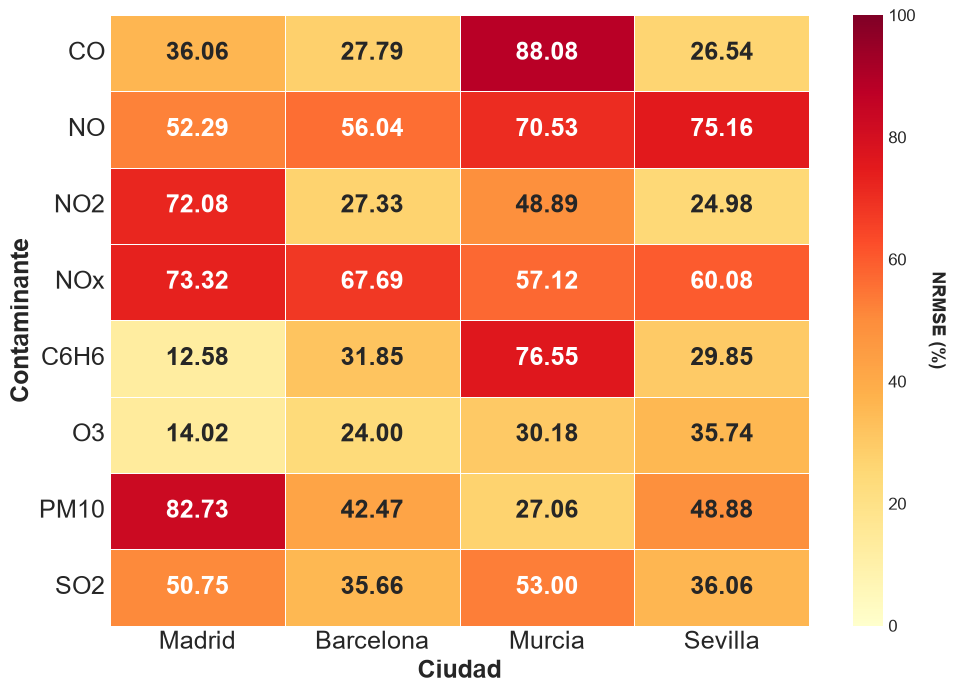

In [35]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ==============================================================================
# Datos de los errores NRMSE de los modelos NeuralProphet
# ==============================================================================

data = {
    "Madrid": {
        "CO": 36.06,
        "NO": 52.29,
        "NO2": 72.08,
        "NOx": 73.32,
        "C6H6": 12.58,
        "O3": 14.02,
        "PM10": 82.73,
        "SO2": 50.75,
    },

    "Barcelona": {
        "CO": 27.79,
        "NO": 56.04,
        "NO2": 27.33,
        "NOx": 67.69,
        "C6H6": 31.85,
        "O3": 24.00,
        "PM10": 42.47,
        "SO2": 35.66,
    },

    "Murcia": {
        "CO": 88.08,
        "NO": 70.53,
        "NO2": 48.89,
        "NOx": 57.12,
        "C6H6": 76.55,
        "O3": 30.18,
        "PM10": 27.06,
        "SO2": 53.00,
    },

    "Sevilla": {
        "CO": 26.54,
        "NO": 75.16,
        "NO2": 24.98,
        "NOx": 60.08,
        "C6H6": 29.85,
        "O3": 35.74,
        "PM10": 48.88,
        "SO2": 36.06,
    },
}


# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_nrmse_neuralprophet = pd.DataFrame(data)


# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")


# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_nrmse_neuralprophet,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "NRMSE (%)"
    }
)


# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

ax.tick_params(
    axis="both",
    length=0
)


# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=12,
    length=0
)

cbar.ax.set_ylabel(
    "NRMSE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)


# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()


# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_nrmse_neuralprophet.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\4085162127.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\4085162127.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\4085162127.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\4085162127.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, tic

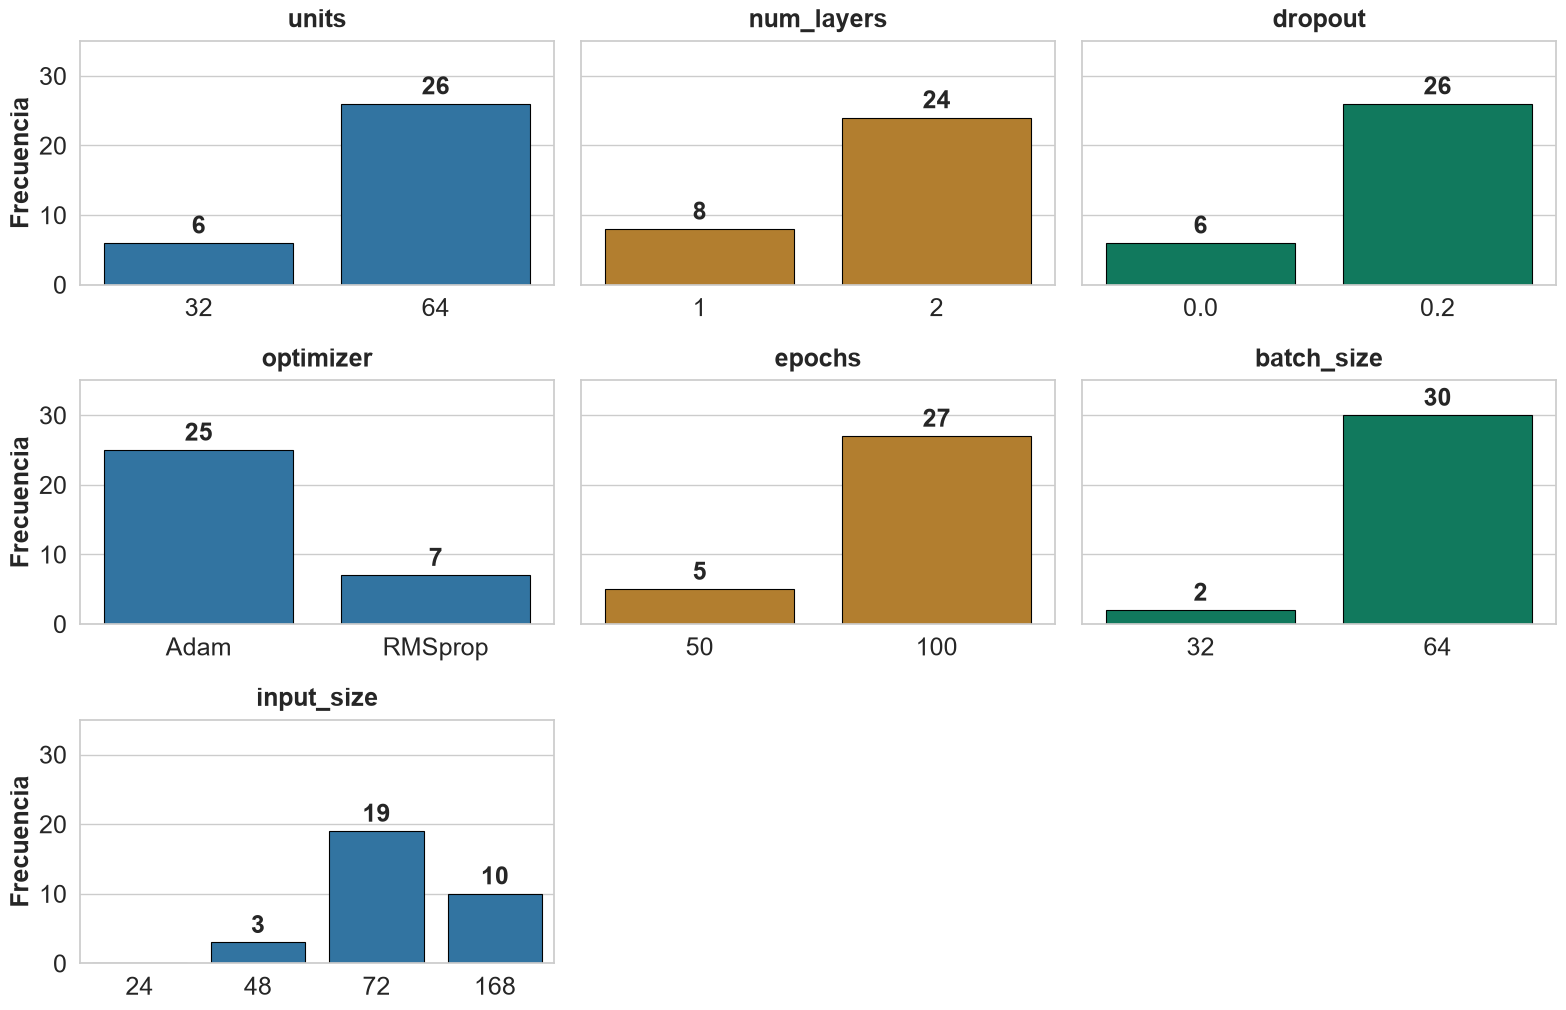

In [36]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ==============================================================================
# Configuración del estilo
# ==============================================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
    }
)


# ==============================================================================
# Frecuencia de selección de los hiperparámetros
# ==============================================================================

data = {

    "units": {
        "32": 6,
        "64": 26
    },

    "num_layers": {
        "1": 8,
        "2": 24
    },

    "dropout": {
        "0.0": 6,
        "0.2": 26
    },

    "optimizer": {
        "Adam": 25,
        "RMSprop": 7
    },

    "epochs": {
        "50": 5,
        "100": 27
    },

    "batch_size": {
        "32": 2,
        "64": 30
    },

    "input_size": {
        "24": 0,
        "48": 3,
        "72": 19,
        "168": 10
    }
}


# ==============================================================================
# Creación de la figura
# ==============================================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 11),
    sharey=True
)

axes = axes.flatten()


# ==============================================================================
# Paleta de colores
# ==============================================================================

colors = [
    "#1f77b4",
    "#c88219",
    "#008a65"
]


# ==============================================================================
# Representación de cada hiperparámetro
# ==============================================================================

for i, (param_name, param_data) in enumerate(data.items()):

    ax = axes[i]

    # --------------------------------------------------------------------------
    # Convertimos el diccionario en DataFrame
    # --------------------------------------------------------------------------

    df_temp = pd.DataFrame(
        list(param_data.items()),
        columns=["Valor", "Frecuencia"]
    )

    # Color según la columna del gráfico
    color = colors[i % 3]

    # --------------------------------------------------------------------------
    # Gráfico de barras
    # --------------------------------------------------------------------------

    bars = sns.barplot(
        data=df_temp,
        x="Valor",
        y="Frecuencia",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------------------
    # Títulos y ejes
    # --------------------------------------------------------------------------

    ax.set_title(
        param_name,
        pad=10,
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Frecuencia" if i % 3 == 0 else "",
        fontsize=18
    )

    ax.set_ylim(0, 35)

    # Tamaño de los valores de los ejes
    ax.tick_params(
        axis="x",
        labelsize=18
    )

    ax.tick_params(
        axis="y",
        labelsize=18
    )

    # --------------------------------------------------------------------------
    # Frecuencia encima de cada barra
    # --------------------------------------------------------------------------

    for p in bars.patches:

        height = p.get_height()

        if height > 0:

            ax.annotate(
                f"{int(height)}",
                (
                    p.get_x() + p.get_width() / 2.0,
                    height
                ),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                fontsize=18,
                fontweight="bold"
            )

    # --------------------------------------------------------------------------
    # Etiquetas del eje X
    # --------------------------------------------------------------------------

    etiquetas = [
        etiqueta.get_text()
        for etiqueta in ax.get_xticklabels()
    ]

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15
        if any(
            len(etiqueta) > 8
            for etiqueta in etiquetas
        )
        else 0,
        fontsize=18
    )


# ==============================================================================
# Eliminamos los subplots vacíos
# ==============================================================================

for j in range(len(data), len(axes)):

    fig.delaxes(
        axes[j]
    )


# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


# ==============================================================================
# Guardar figura
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "hiperparametros_lstm_barras.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

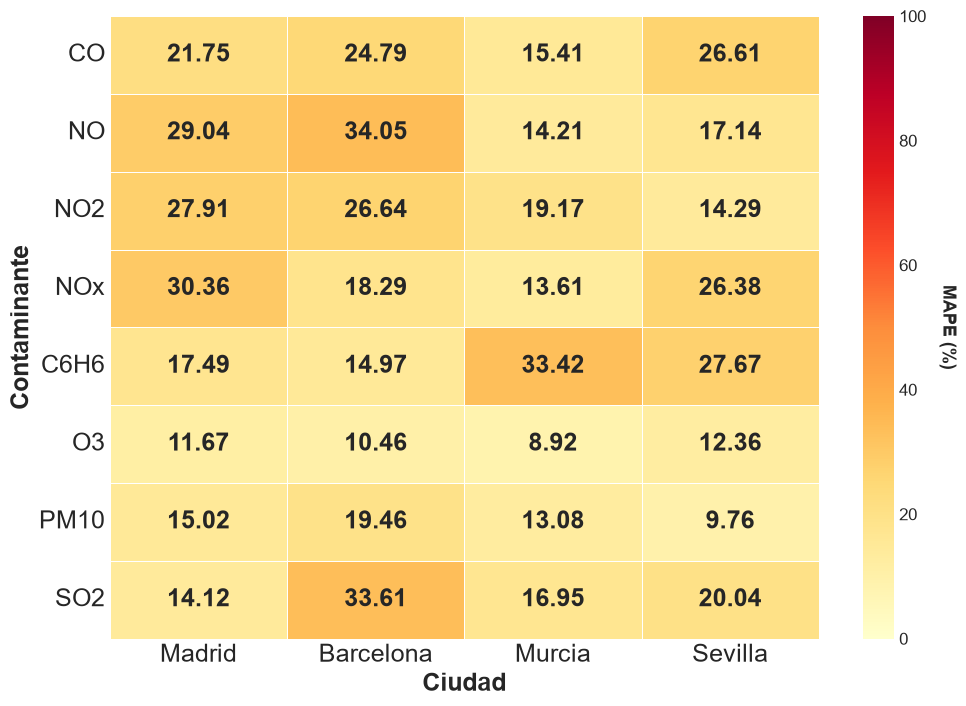

In [37]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# Datos de los errores MAPE de los modelos LSTM
# ==============================================================================

data = {
    "Madrid": {
        "CO": 21.75,
        "NO": 29.04,
        "NO2": 27.91,
        "NOx": 30.36,
        "C6H6": 17.49,
        "O3": 11.67,
        "PM10": 15.02,
        "SO2": 14.12,
    },

    "Barcelona": {
        "CO": 24.79,
        "NO": 34.05,
        "NO2": 26.64,
        "NOx": 18.29,
        "C6H6": 14.97,
        "O3": 10.46,
        "PM10": 19.46,
        "SO2": 33.61,
    },

    "Murcia": {
        "CO": 15.41,
        "NO": 14.21,
        "NO2": 19.17,
        "NOx": 13.61,
        "C6H6": 33.42,
        "O3": 8.92,
        "PM10": 13.08,
        "SO2": 16.95,
    },

    "Sevilla": {
        "CO": 26.61,
        "NO": 17.14,
        "NO2": 14.29,
        "NOx": 26.38,
        "C6H6": 27.67,
        "O3": 12.36,
        "PM10": 9.76,
        "SO2": 20.04,
    },
}

# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_mape_lstm = pd.DataFrame(data)

# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")

# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_mape_lstm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "MAPE (%)"
    }
)

# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

ax.tick_params(
    axis="both",
    length=0
)

# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=12,
    length=0
)

cbar.ax.set_ylabel(
    "MAPE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()

# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_mape_lstm.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

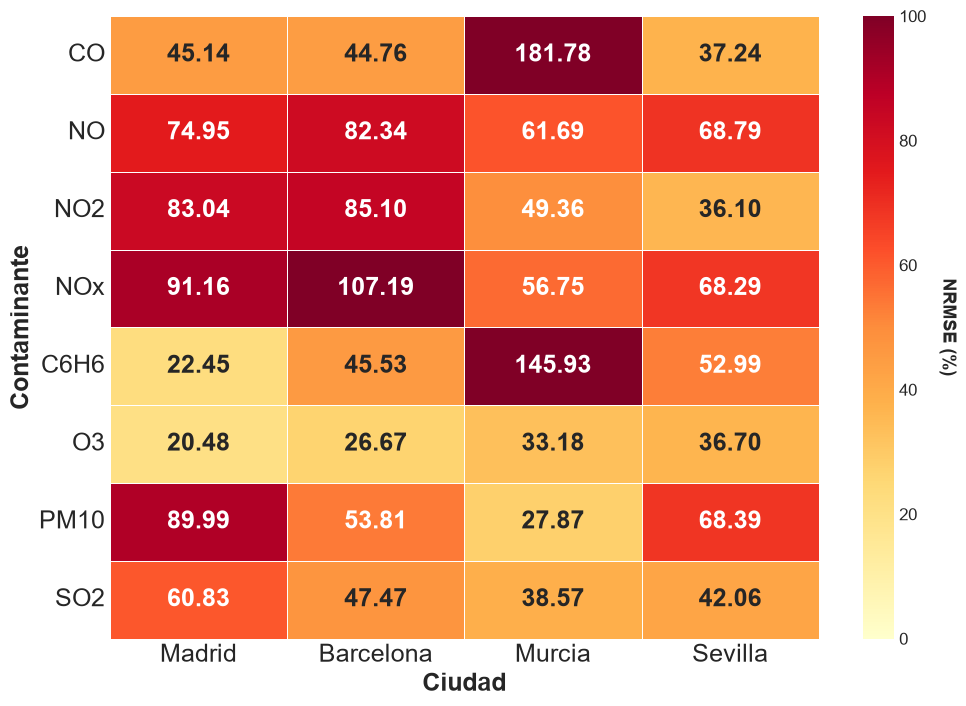

In [38]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# Datos de los errores NRMSE de los modelos LSTM
# ==============================================================================

data = {
    "Madrid": {
        "CO": 45.14,
        "NO": 74.95,
        "NO2": 83.04,
        "NOx": 91.16,
        "C6H6": 22.45,
        "O3": 20.48,
        "PM10": 89.99,
        "SO2": 60.83,
    },

    "Barcelona": {
        "CO": 44.76,
        "NO": 82.34,
        "NO2": 85.10,
        "NOx": 107.19,
        "C6H6": 45.53,
        "O3": 26.67,
        "PM10": 53.81,
        "SO2": 47.47,
    },

    "Murcia": {
        "CO": 181.78,
        "NO": 61.69,
        "NO2": 49.36,
        "NOx": 56.75,
        "C6H6": 145.93,
        "O3": 33.18,
        "PM10": 27.87,
        "SO2": 38.57,
    },

    "Sevilla": {
        "CO": 37.24,
        "NO": 68.79,
        "NO2": 36.10,
        "NOx": 68.29,
        "C6H6": 52.99,
        "O3": 36.70,
        "PM10": 68.39,
        "SO2": 42.06,
    },
}

# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_nrmse_lstm = pd.DataFrame(data)

# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")

# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_nrmse_lstm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "NRMSE (%)"
    }
)

# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

ax.tick_params(
    axis="both",
    length=0
)

# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=12,
    length=0
)

cbar.ax.set_ylabel(
    "NRMSE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()

# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_nrmse_lstm.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\824458646.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\824458646.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\824458646.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\824458646.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks m

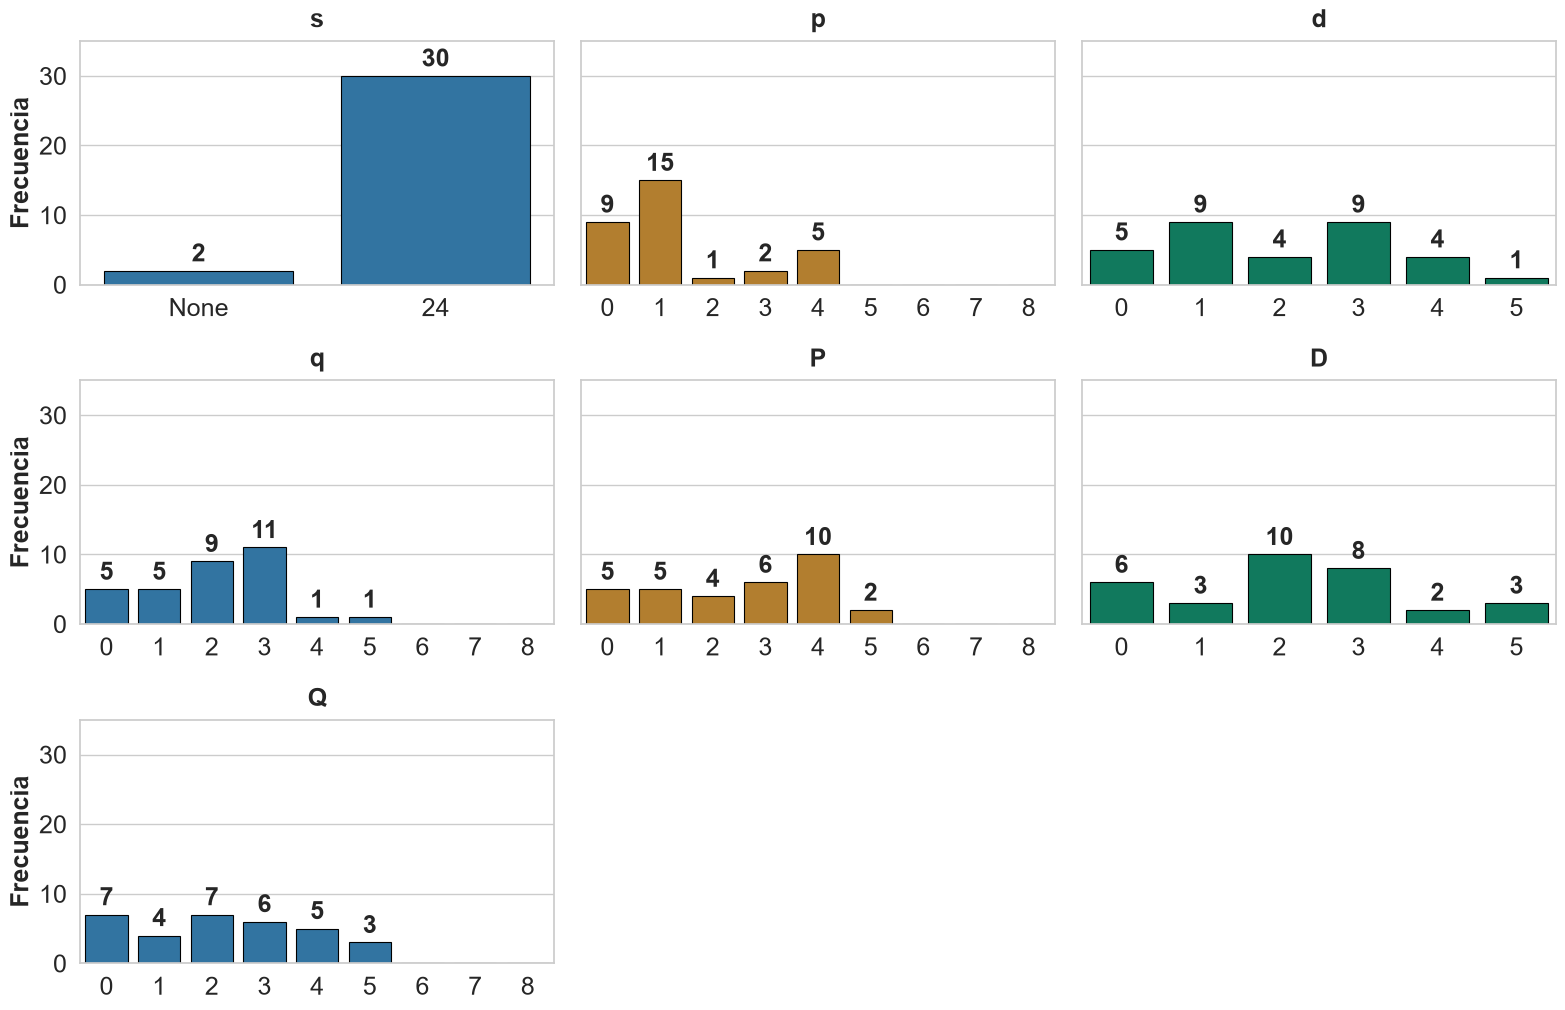

In [39]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# Configuración del estilo
# ==============================================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
    }
)

# ==============================================================================
# Frecuencia de selección de los hiperparámetros
# ==============================================================================

data = {

    "s": {
        "None": 2,
        "24": 30
    },

    "p": {
        "0": 9,
        "1": 15,
        "2": 1,
        "3": 2,
        "4": 5,
        "5": 0,
        "6": 0,
        "7": 0,
        "8": 0
    },

    "d": {
        "0": 5,
        "1": 9,
        "2": 4,
        "3": 9,
        "4": 4,
        "5": 1
    },

    "q": {
        "0": 5,
        "1": 5,
        "2": 9,
        "3": 11,
        "4": 1,
        "5": 1,
        "6": 0,
        "7": 0,
        "8": 0
    },

    "P": {
        "0": 5,
        "1": 5,
        "2": 4,
        "3": 6,
        "4": 10,
        "5": 2,
        "6": 0,
        "7": 0,
        "8": 0
    },

    "D": {
        "0": 6,
        "1": 3,
        "2": 10,
        "3": 8,
        "4": 2,
        "5": 3
    },

    "Q": {
        "0": 7,
        "1": 4,
        "2": 7,
        "3": 6,
        "4": 5,
        "5": 3,
        "6": 0,
        "7": 0,
        "8": 0
    }
}

# ==============================================================================
# Creación de la figura
# ==============================================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 11),
    sharey=True
)

axes = axes.flatten()

# ==============================================================================
# Paleta de colores
# ==============================================================================

colors = [
    "#1f77b4",
    "#c88219",
    "#008a65"
]

# ==============================================================================
# Representación de cada hiperparámetro
# ==============================================================================

for i, (param_name, param_data) in enumerate(data.items()):

    ax = axes[i]

    # Convertimos el diccionario en DataFrame
    df_temp = pd.DataFrame(
        list(param_data.items()),
        columns=["Valor", "Frecuencia"]
    )

    # Color según la columna del gráfico
    color = colors[i % 3]

    # Gráfico de barras
    bars = sns.barplot(
        data=df_temp,
        x="Valor",
        y="Frecuencia",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------------------
    # Títulos y ejes
    # --------------------------------------------------------------------------

    ax.set_title(
        param_name,
        pad=10,
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Frecuencia" if i % 3 == 0 else "",
        fontsize=18
    )

    ax.set_ylim(0, 35)

    # Tamaño de los valores de los ejes
    ax.tick_params(
        axis="x",
        labelsize=18
    )

    ax.tick_params(
        axis="y",
        labelsize=18
    )

    # --------------------------------------------------------------------------
    # Frecuencia encima de cada barra
    # --------------------------------------------------------------------------

    for p in bars.patches:

        height = p.get_height()

        if height > 0:

            ax.annotate(
                f"{int(height)}",
                (
                    p.get_x() + p.get_width() / 2.0,
                    height
                ),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                fontsize=18,
                fontweight="bold"
            )

    # --------------------------------------------------------------------------
    # Etiquetas del eje X
    # --------------------------------------------------------------------------

    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=18
    )

# ==============================================================================
# Eliminamos los subplots vacíos
# ==============================================================================

for j in range(len(data), len(axes)):
    fig.delaxes(axes[j])

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

# ==============================================================================
# Guardar figura
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "hiperparametros_sarimax_barras.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300
)

plt.show()

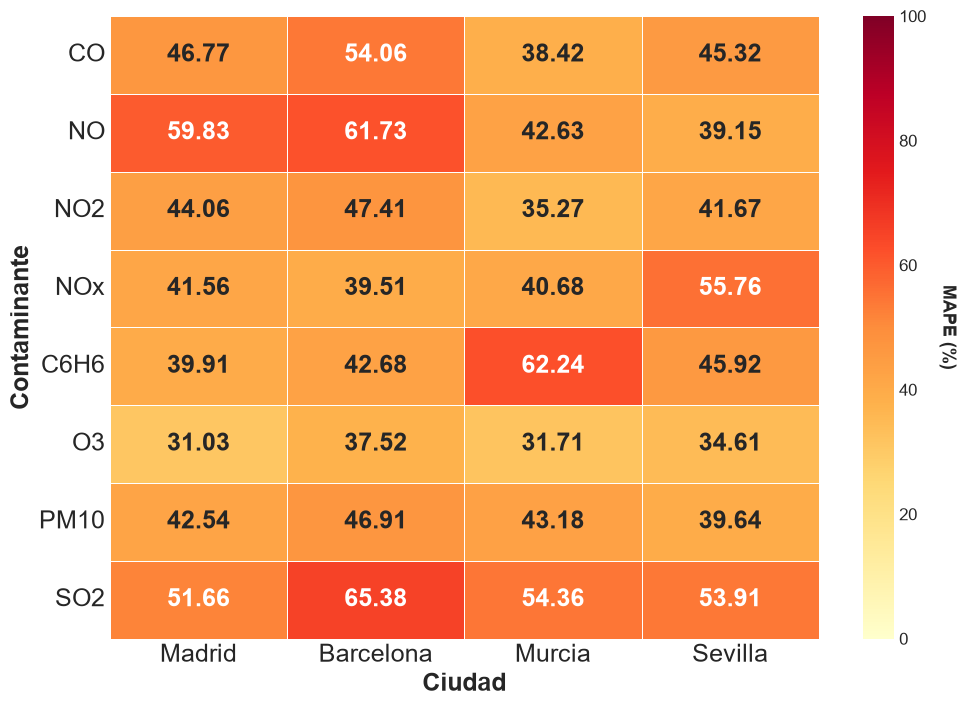

In [40]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# Datos de los errores MAPE de los modelos SARIMAX
# ==============================================================================

data = {
    "Madrid": {
        "CO": 46.77,
        "NO": 59.83,
        "NO2": 44.06,
        "NOx": 41.56,
        "C6H6": 39.91,
        "O3": 31.03,
        "PM10": 42.54,
        "SO2": 51.66,
    },

    "Barcelona": {
        "CO": 54.06,
        "NO": 61.73,
        "NO2": 47.41,
        "NOx": 39.51,
        "C6H6": 42.68,
        "O3": 37.52,
        "PM10": 46.91,
        "SO2": 65.38,
    },

    "Murcia": {
        "CO": 38.42,
        "NO": 42.63,
        "NO2": 35.27,
        "NOx": 40.68,
        "C6H6": 62.24,
        "O3": 31.71,
        "PM10": 43.18,
        "SO2": 54.36,
    },

    "Sevilla": {
        "CO": 45.32,
        "NO": 39.15,
        "NO2": 41.67,
        "NOx": 55.76,
        "C6H6": 45.92,
        "O3": 34.61,
        "PM10": 39.64,
        "SO2": 53.91,
    },
}

# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_mape_sarimax = pd.DataFrame(data)

# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")

# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_mape_sarimax,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "MAPE (%)"
    }
)

# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

# Etiquetas de las ciudades
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

# Etiquetas de los contaminantes
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# Quitamos las marcas de los ejes
ax.tick_params(
    axis="both",
    length=0
)

# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

# Números de la barra de color
cbar.ax.tick_params(
    labelsize=12,
    length=0
)

# Etiqueta de la barra
cbar.ax.set_ylabel(
    "MAPE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()

# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_mape_sarimax.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

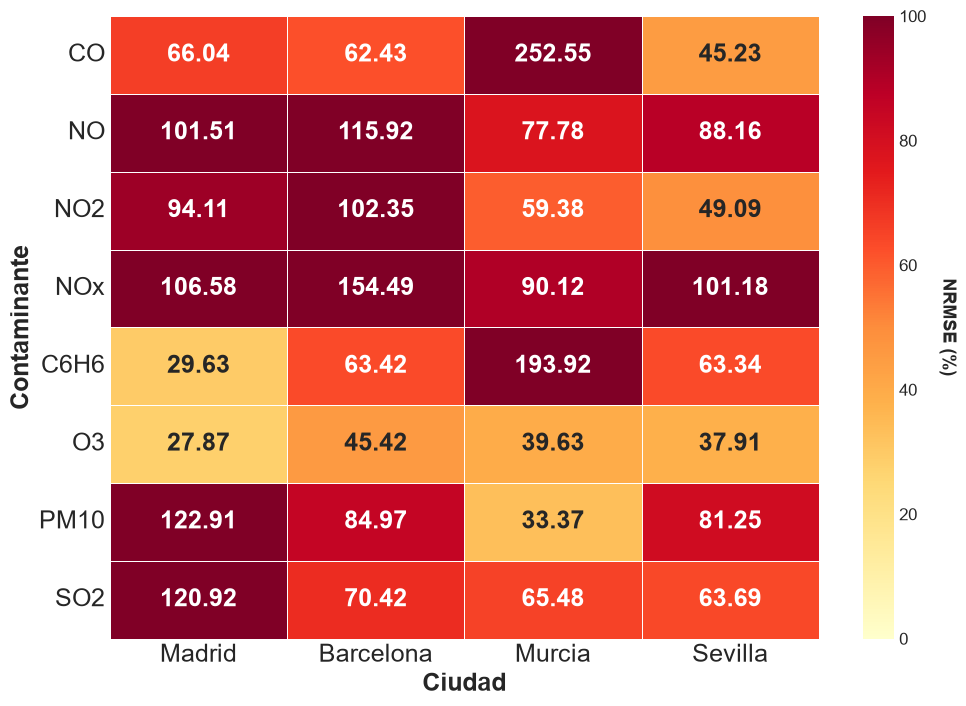

In [41]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==============================================================================
# Datos de los errores NRMSE de los modelos SARIMAX
# ==============================================================================

data = {
    "Madrid": {
        "CO": 66.04,
        "NO": 101.51,
        "NO2": 94.11,
        "NOx": 106.58,
        "C6H6": 29.63,
        "O3": 27.87,
        "PM10": 122.91,
        "SO2": 120.92,
    },

    "Barcelona": {
        "CO": 62.43,
        "NO": 115.92,
        "NO2": 102.35,
        "NOx": 154.49,
        "C6H6": 63.42,
        "O3": 45.42,
        "PM10": 84.97,
        "SO2": 70.42,
    },

    "Murcia": {
        "CO": 252.55,
        "NO": 77.78,
        "NO2": 59.38,
        "NOx": 90.12,
        "C6H6": 193.92,
        "O3": 39.63,
        "PM10": 33.37,
        "SO2": 65.48,
    },

    "Sevilla": {
        "CO": 45.23,
        "NO": 88.16,
        "NO2": 49.09,
        "NOx": 101.18,
        "C6H6": 63.34,
        "O3": 37.91,
        "PM10": 81.25,
        "SO2": 63.69,
    },
}

# ==============================================================================
# Conversión de los datos en un DataFrame
# ==============================================================================

df_nrmse_sarimax = pd.DataFrame(data)

# ==============================================================================
# Configuración de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(10.4, 7.4)
)

fig.patch.set_facecolor("white")

# ==============================================================================
# Creación del mapa de calor
# ==============================================================================

ax = sns.heatmap(
    df_nrmse_sarimax,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "NRMSE (%)"
    }
)

# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

# Etiquetas de las ciudades
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

# Etiquetas de los contaminantes
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# Quitamos las marcas de los ejes
ax.tick_params(
    axis="both",
    length=0
)

# ==============================================================================
# Formato de la barra de color
# ==============================================================================

cbar = ax.collections[0].colorbar

# Números de la barra de color
cbar.ax.tick_params(
    labelsize=12,
    length=0
)

# Etiqueta de la barra
cbar.ax.set_ylabel(
    "NRMSE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()

# ==============================================================================
# Guardado y presentación
# ==============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_nrmse_sarimax.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_13060\119407400.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_codigo = df_modelo.replace(


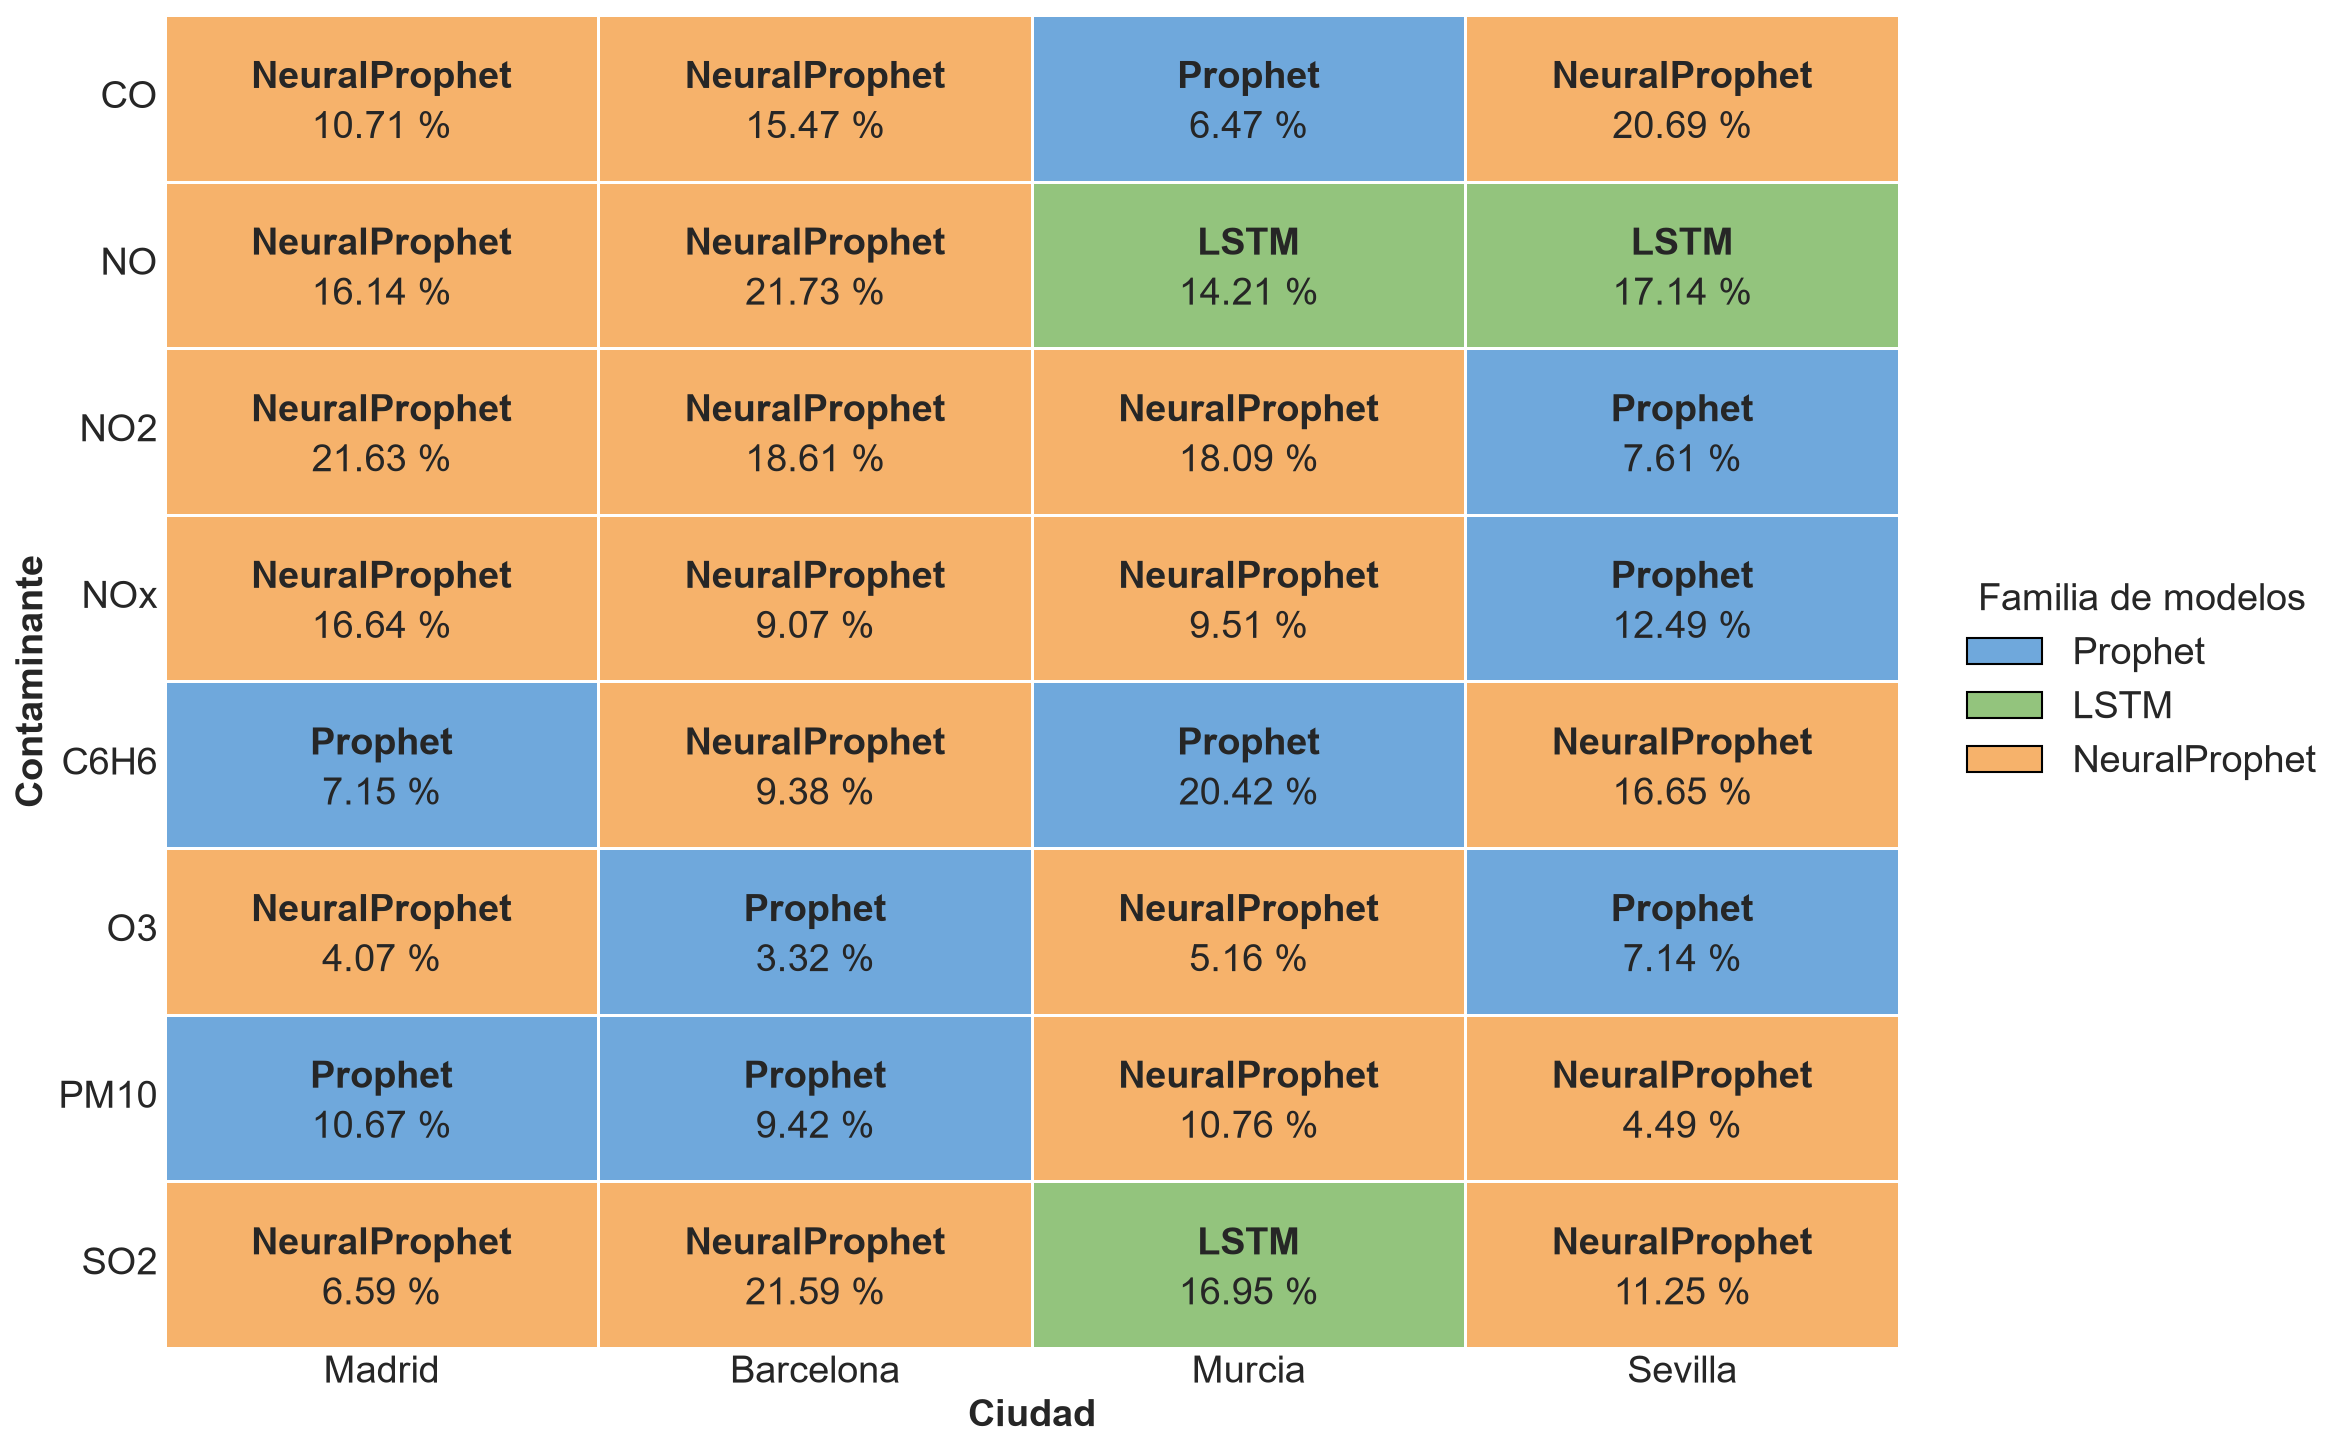

In [42]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ==============================================================================
# Datos: mejor modelo
# ==============================================================================

data_modelo = {

    "Madrid": {
        "CO": "NeuralProphet",
        "NO": "NeuralProphet",
        "NO2": "NeuralProphet",
        "NOx": "NeuralProphet",
        "C6H6": "Prophet",
        "O3": "NeuralProphet",
        "PM10": "Prophet",
        "SO2": "NeuralProphet",
    },

    "Barcelona": {
        "CO": "NeuralProphet",
        "NO": "NeuralProphet",
        "NO2": "NeuralProphet",
        "NOx": "NeuralProphet",
        "C6H6": "NeuralProphet",
        "O3": "Prophet",
        "PM10": "Prophet",
        "SO2": "NeuralProphet",
    },

    "Murcia": {
        "CO": "Prophet",
        "NO": "LSTM",
        "NO2": "NeuralProphet",
        "NOx": "NeuralProphet",
        "C6H6": "Prophet",
        "O3": "NeuralProphet",
        "PM10": "NeuralProphet",
        "SO2": "LSTM",
    },

    "Sevilla": {
        "CO": "NeuralProphet",
        "NO": "LSTM",
        "NO2": "Prophet",
        "NOx": "Prophet",
        "C6H6": "NeuralProphet",
        "O3": "Prophet",
        "PM10": "NeuralProphet",
        "SO2": "NeuralProphet",
    },
}

# ==============================================================================
# Datos: error MAPE
# ==============================================================================

data_mape = {

    "Madrid": {
        "CO": 10.71,
        "NO": 16.14,
        "NO2": 21.63,
        "NOx": 16.64,
        "C6H6": 7.15,
        "O3": 4.07,
        "PM10": 10.67,
        "SO2": 6.59,
    },

    "Barcelona": {
        "CO": 15.47,
        "NO": 21.73,
        "NO2": 18.61,
        "NOx": 9.07,
        "C6H6": 9.38,
        "O3": 3.32,
        "PM10": 9.42,
        "SO2": 21.59,
    },

    "Murcia": {
        "CO": 6.47,
        "NO": 14.21,
        "NO2": 18.09,
        "NOx": 9.51,
        "C6H6": 20.42,
        "O3": 5.16,
        "PM10": 10.76,
        "SO2": 16.95,
    },

    "Sevilla": {
        "CO": 20.69,
        "NO": 17.14,
        "NO2": 7.61,
        "NOx": 12.49,
        "C6H6": 16.65,
        "O3": 7.14,
        "PM10": 4.49,
        "SO2": 11.25,
    },
}

# ==============================================================================
# Conversión de los datos en DataFrame
# ==============================================================================

df_modelo = pd.DataFrame(data_modelo)
df_mape = pd.DataFrame(data_mape)

# ==============================================================================
# Codificación numérica de las familias de modelos
# ==============================================================================

modelo_codigo = {
    "Prophet": 0,
    "LSTM": 1,
    "NeuralProphet": 2
}

df_codigo = df_modelo.replace(
    modelo_codigo
).astype(int)

# ==============================================================================
# Mapa de colores
# ==============================================================================

cmap = ListedColormap([
    "#6FA8DC",   # Azul - Prophet
    "#93C47D",   # Verde - LSTM
    "#F6B26B"    # Naranja - NeuralProphet
])

# ==============================================================================
# Configuración del estilo
# ==============================================================================

sns.set_theme(
    style="white"
)

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.labelsize": 18,
        "axes.labelweight": "bold",
        "xtick.labelsize": 18,
        "ytick.labelsize": 18
    }
)

# ==============================================================================
# Creación de la figura
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(16, 10),
    dpi=150
)

fig.patch.set_facecolor("white")

# ==============================================================================
# Creación del mapa categórico
# ==============================================================================

sns.heatmap(
    df_codigo,
    cmap=cmap,
    cbar=False,
    linewidths=1.2,
    linecolor="white",
    annot=False,
    ax=ax
)

# ==============================================================================
# Anotaciones: modelo + MAPE
# ==============================================================================

for i, contaminante in enumerate(df_modelo.index):

    for j, ciudad in enumerate(df_modelo.columns):

        modelo = df_modelo.loc[
            contaminante,
            ciudad
        ]

        mape = df_mape.loc[
            contaminante,
            ciudad
        ]

        # ----------------------------------------------------------------------
        # Nombre del modelo
        # ----------------------------------------------------------------------

        ax.text(
            j + 0.5,
            i + 0.38,
            modelo,
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )

        # ----------------------------------------------------------------------
        # Error MAPE
        # ----------------------------------------------------------------------

        ax.text(
            j + 0.5,
            i + 0.68,
            f"{mape:.2f} %",
            ha="center",
            va="center",
            fontsize=18
        )

# ==============================================================================
# Personalización del gráfico
# ==============================================================================

ax.set_xlabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

# Tamaño de las etiquetas de los ejes
ax.tick_params(
    axis="both",
    labelsize=18,
    length=0
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# ==============================================================================
# Leyenda de familias de modelos
# ==============================================================================

legend_elements = [

    Patch(
        facecolor="#6FA8DC",
        edgecolor="black",
        label="Prophet"
    ),

    Patch(
        facecolor="#93C47D",
        edgecolor="black",
        label="LSTM"
    ),

    Patch(
        facecolor="#F6B26B",
        edgecolor="black",
        label="NeuralProphet"
    )
]

ax.legend(
    handles=legend_elements,
    title="Familia de modelos",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=18,
    title_fontsize=18
)

# ==============================================================================
# Ajuste del diseño
# ==============================================================================

plt.tight_layout()

# ==============================================================================
# Guardado en PNG de alta resolución
# ==============================================================================

file_path_png = os.path.join(
    output_dir,
    "mejor_modelo_mape_ciudad_contaminante.png"
)

plt.savefig(
    file_path_png,
    bbox_inches="tight",
    dpi=600,
    facecolor="white"
)

# ==============================================================================
# Presentación
# ==============================================================================

plt.show()

,CO,NO,NO2,NOx,C6H6,O3,PM10,SO2
Madrid,11.70,18.51,20.37,17.24,6.47,4.91,12.63,6.36
Barcelona,13.21,24.08,15.29,10.16,8.47,5.71,9.71,15.57
Murcia,8.43,18.92,17.26,6.78,18.61,7.59,8.34,18.63
Sevilla,16.24,21.44,8.52,15.27,17.22,9.62,5.31,13.47


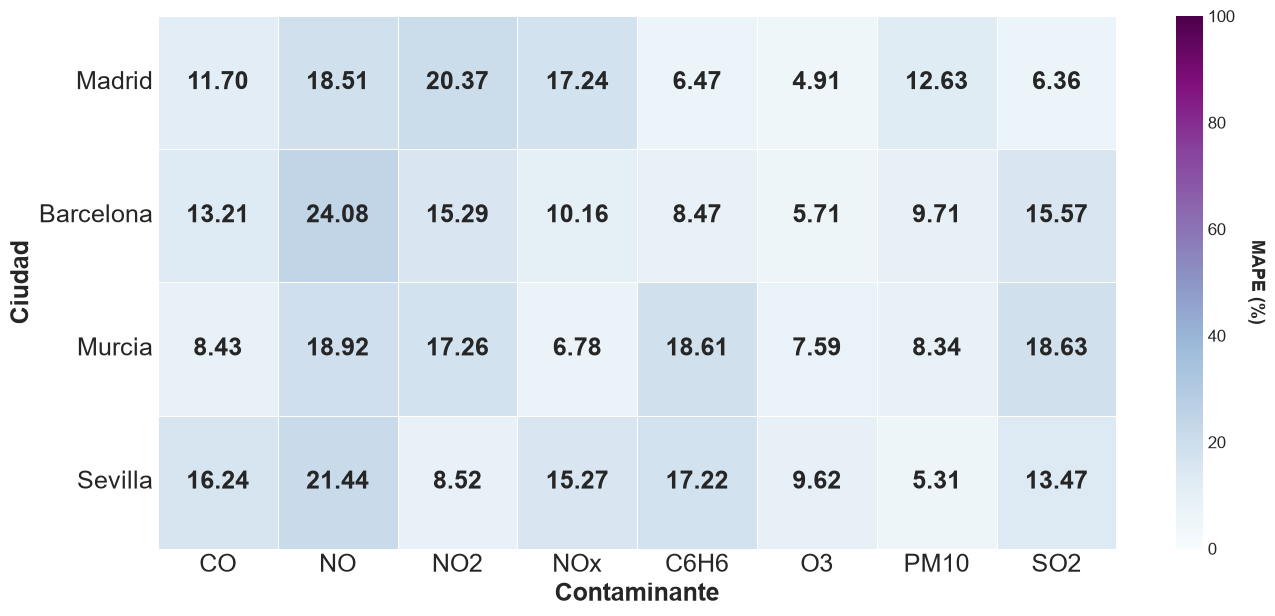

In [44]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =============================================================================
# 1. ERRORES MAPE DE GENERALIZACIÓN
# =============================================================================

data = {
    "Madrid": {
        "CO": 11.70,
        "NO": 18.51,
        "NO2": 20.37,
        "NOx": 17.24,
        "C6H6": 6.47,
        "O3": 4.91,
        "PM10": 12.63,
        "SO2": 6.36,
    },
    "Barcelona": {
        "CO": 13.21,
        "NO": 24.08,
        "NO2": 15.29,
        "NOx": 10.16,
        "C6H6": 8.47,
        "O3": 5.71,
        "PM10": 9.71,
        "SO2": 15.57,
    },
    "Murcia": {
        "CO": 8.43,
        "NO": 18.92,
        "NO2": 17.26,
        "NOx": 6.78,
        "C6H6": 18.61,
        "O3": 7.59,
        "PM10": 8.34,
        "SO2": 18.63,
    },
    "Sevilla": {
        "CO": 16.24,
        "NO": 21.44,
        "NO2": 8.52,
        "NOx": 15.27,
        "C6H6": 17.22,
        "O3": 9.62,
        "PM10": 5.31,
        "SO2": 13.47,
    },
}

# =============================================================================
# 2. CONVERSIÓN A DATAFRAME
# =============================================================================

df_mape_generalizacion = pd.DataFrame(data)

# Transponemos el DataFrame para que:
# - Eje X: contaminantes
# - Eje Y: ciudades
df_mape_generalizacion = df_mape_generalizacion.T

display(df_mape_generalizacion)

# =============================================================================
# 3. CONFIGURACIÓN DE LA FIGURA
# =============================================================================

fig, ax = plt.subplots(
    figsize=(14, 6.5)
)

fig.patch.set_facecolor("white")

# =============================================================================
# 4. MAPA DE CALOR
# =============================================================================

ax = sns.heatmap(
    df_mape_generalizacion,
    annot=True,
    fmt=".2f",
    cmap="BuPu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={
        "fontsize": 18,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "MAPE (%)"
    }
)

# =============================================================================
# 5. PERSONALIZACIÓN
# =============================================================================

ax.set_xlabel(
    "Contaminante",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Ciudad",
    fontsize=18,
    fontweight="bold"
)

# Etiquetas de los contaminantes
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=18
)

# Etiquetas de las ciudades
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=18
)

# Quitamos las marcas de los ejes
ax.tick_params(
    axis="both",
    length=0
)

# =============================================================================
# 6. FORMATO DE LA BARRA DE COLOR
# =============================================================================

cbar = ax.collections[0].colorbar

# Números de la barra de color
cbar.ax.tick_params(
    labelsize=12,
    length=0
)

# Etiqueta de la barra
cbar.ax.set_ylabel(
    "MAPE (%)",
    rotation=270,
    labelpad=22,
    fontsize=13
)

cbar.outline.set_visible(False)

# =============================================================================
# 7. AJUSTE DEL DISEÑO
# =============================================================================

plt.tight_layout()

# =============================================================================
# 8. GUARDADO DE LA FIGURA
# =============================================================================

file_path = os.path.join(
    output_dir,
    "mapa_calor_mape_generalizacion.png"
)

plt.savefig(
    file_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

plt.show()